<a href="https://colab.research.google.com/github/wdohoon/wdohoon/blob/main/ex11)_SimpleRNN_%EC%82%AC%EC%9A%A9%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###목표
- 간단한 데이터를 만들어서 RNN의 구조를 익혀보자!

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### 데이터셋 구축하기
- 문자 하나하나를 단위로 RNN을 사용해보자
- hello, apple, lobby, daddy, bobby

In [ ]:
# 문제 데이터는 hell, appl, lobb, dadd, bobb
# 정답 데이터는 o, e, y, y, y

# timesteps는 4

#### 원핫인코딩으로 문자를 숫자로 변경
- 문제 + 정답 전체 데이터에서 등장하는 문자는 h, e, l, o, a, p, b, y, d 로 총 9개

In [ ]:
# 문제 데이터
X_train = np.array([[[1,0,0,0,0,0,0,0,0], [0,1,0,0,0,0,0,0,0], [0,0,1,0,0,0,0,0,0], [0,0,1,0,0,0,0,0,0]],   # h,e,l,l
                    [[0,0,0,0,1,0,0,0,0], [0,0,0,0,0,1,0,0,0], [0,0,0,0,0,1,0,0,0], [0,0,1,0,0,0,0,0,0]],   # a,p,p,l
                    [[0,0,1,0,0,0,0,0,0], [0,0,0,1,0,0,0,0,0], [0,0,0,0,0,0,1,0,0], [0,0,0,0,0,0,1,0,0]],   # l,o,b,b
                    [[0,0,0,0,0,0,0,0,1], [0,0,0,0,1,0,0,0,0], [0,0,0,0,0,0,0,0,1], [0,0,0,0,0,0,0,0,1]],   # d,a,d,d
                    [[0,0,0,0,0,0,1,0,0], [0,0,0,1,0,0,0,0,0], [0,0,0,0,0,0,1,0,0], [0,0,0,0,0,0,1,0,0]],   # b,o,b,b
                    ])

In [ ]:
# 정답 데이터
y_train = np.array([[0,0,0,1,0,0,0,0,0],   # o
                    [0,1,0,0,0,0,0,0,0],   # e
                    [0,0,0,0,0,0,0,1,0],   # y
                    [0,0,0,0,0,0,0,1,0],   # y
                    [0,0,0,0,0,0,0,1,0]    # y
                    ])

In [ ]:
X_train.shape, y_train.shape
# samples(샘플 수), timesteps(순환횟수), features(특성 수 = 원핫인코딩 된 컬럼 수)

((5, 4, 9), (5, 9))

#### 출력되는 값을 알파벳 전체로 하고 싶다면 26개로 원핫인코딩 하면 됨
- 현재는 RNN의 구조를 알아보기 위해 간단히 9개 문자로만 문제와 정답을 설정한 상태

RNN 신경망 모델링

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [ ]:
model = Sequential()

# 입력층 + SimpleRNN층 1개
# 8개의 뉴런을 가지고 각 뉴런이 4번씩 순환하며 각 순환마다 9개의 숫자가 들어감
model.add(SimpleRNN(8, input_shape=(4, 9)))

# 출력층
model.add(Dense(9, activation='softmax'))

model.summary()

# RNN은 가중치가 두 종류가 있음(과거데이터의 가중치, 현재데이터의 가중치)
# 현재데이터의 가중치 -> 9(입력특성) * 8(RNN층 뉴런수) + 8(RNN층 뉴런수 = b값)
# 과거데이터의 가중치 -> 8(RNN층 뉴런수) * 8(RNN층 뉴런수)
# RNN층의 각 뉴런들이 뽑아낸 결과는 다시 같은 층의 모든 뉴런들에게 과거데이터로 들어가게 됨

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 8)                 144       
                                                                 
 dense (Dense)               (None, 9)                 81        
                                                                 
Total params: 225
Trainable params: 225
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer='Adam',
              metrics=['acc'])

In [ ]:
h= model.fit(X_train, y_train, epochs=200)

Epoch 1/200
1/1 [==============================] - 6s 6s/step - loss: 2.1440 - acc: 0.2000
Epoch 2/200
1/1 [==============================] - 0s 12ms/step - loss: 2.1315 - acc: 0.2000
Epoch 3/200
1/1 [==============================] - 0s 11ms/step - loss: 2.1190 - acc: 0.2000
Epoch 4/200
1/1 [==============================] - 0s 12ms/step - loss: 2.1066 - acc: 0.2000
Epoch 5/200
1/1 [==============================] - 0s 16ms/step - loss: 2.0943 - acc: 0.2000
Epoch 6/200
1/1 [==============================] - 0s 13ms/step - loss: 2.0819 - acc: 0.2000
Epoch 7/200
1/1 [==============================] - 0s 15ms/step - loss: 2.0697 - acc: 0.2000
Epoch 8/200
1/1 [==============================] - 0s 15ms/step - loss: 2.0575 - acc: 0.2000
Epoch 9/200
1/1 [==============================] - 0s 13ms/step - loss: 2.0453 - acc: 0.2000
Epoch 10/200
1/1 [==============================] - 0s 13ms/step - loss: 2.0332 - acc: 0.2000
Epoch 11/200
1/1 [==============================] - 0s 12ms/step - loss

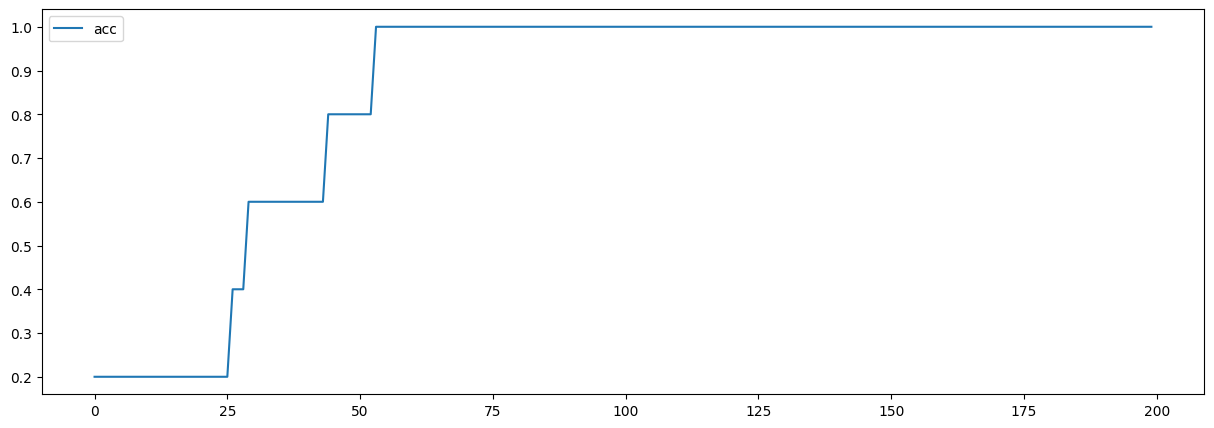

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(h.history['acc'], label='acc')
plt.legend()
plt.show()

In [ ]:
# apple을 넣어서 e가 잘 나오는지 확인해보자!
input_word = np.array( [[[0,0,0,0,1,0,0,0,0],
                        [0,0,0,0,0,1,0,0,0],
                        [0,0,0,0,0,1,0,0,0],
                        [0,0,1,0,0,0,0,0,0]]])
input_word.shape

(1, 4, 9)

In [ ]:
model.predict(input_word)
# h, e, l, o, a ,p, b, y, d 순서대로 확률값이 출력

1/1 [==============================] - 0s 135ms/step


array([[0.02419902, 0.6059662 , 0.09177887, 0.03059856, 0.03954925,
        0.06428261, 0.104248  , 0.01652507, 0.02285237]], dtype=float32)